In [1]:
# Imports
from scipy import stats

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix
import statsmodels.api as sm

# Part 1: Data Collection and Preparation

In [2]:
tickers = ["JPM", "BAC", "C", "BNP.PA", "DBK.DE"]
start = "2022-01-01"
end = "2026-05-01"
interval = "1d"

In [3]:
#Data downloading and saving
# Close price is used because it is the most widely used in literature.
data = yf.download(tickers=tickers, start=start, end=end, interval=interval, auto_adjust=True)["Close"] # adjusted for splits and dividents
data.head(5)
data.to_csv("data_bank/close_prices_full.csv")

[*********************100%***********************]  5 of 5 completed


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1117 entries, 2022-01-03 to 2026-04-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   BAC     1085 non-null   float64
 1   BNP.PA  1106 non-null   float64
 2   C       1085 non-null   float64
 3   DBK.DE  1102 non-null   float64
 4   JPM     1085 non-null   float64
dtypes: float64(5)
memory usage: 52.4 KB


Since the stocks trade on different exchanges, the raw price data contains some missing observations caused by non-overlapping trading days and market holidays. Therefore, returns are computed first and then missing observations are removed. The final return dataset contains 1024 common daily observations across all five banks.

In [5]:
daily_returns = (data - data.shift(1)) /  data.shift(1)
daily_returns = daily_returns.dropna()

log_daily_returns = np.log(data / data.shift(1))
log_daily_returns = log_daily_returns.dropna()

# Save to csv for later usage
daily_returns.to_csv("data_bank/daily_returns_full.csv")
log_daily_returns.to_csv("data_bank/log_daily_returns_full.csv")

# Part 2: Descriptive Statistics

In [6]:
colors = {
    "JPM": "#1f77b4",
    "BAC": "#ff7f0e",
    "C": "#2ca02c",
    "BNP.PA": "#d62728",
    "DBK.DE": "#9467bd"
}

rolling_window = 25 # Month has 25 trading days

Plot 1: Price and its moving average

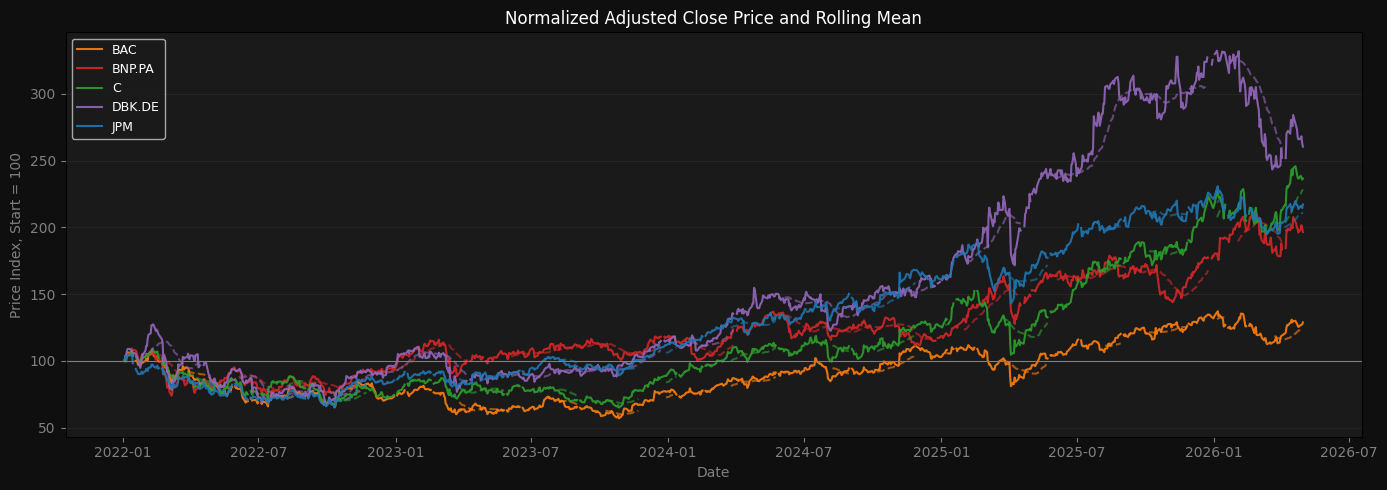

In [7]:
normalized_prices = data / data.iloc[0] * 100

fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor("#0F0F0F")
ax.set_facecolor("#1A1A1A")

for ticker in normalized_prices.columns:
    ax.plot(
        normalized_prices.index,
        normalized_prices[ticker],
        color=colors[ticker],
        label=ticker,
        alpha=0.9
    )
    ax.plot(
        normalized_prices.index,
        normalized_prices[ticker].rolling(rolling_window).mean(),
        color=colors[ticker],
        linestyle="--",
        alpha=0.6
    )

ax.axhline(100, color="gray", linewidth=0.8)
ax.tick_params(colors="gray")
ax.set_title("Normalized Adjusted Close Price and Rolling Mean", color="white")
ax.set_ylabel("Price Index, Start = 100", color="gray")
ax.grid(axis="y", color="#2A2A2A", linewidth=0.5)
ax.set_xlabel("Date", color="gray")
ax.legend(facecolor="#1A1A1A", labelcolor="white", framealpha=0.8, fontsize=9)

plt.tight_layout()
plt.savefig("plots_bank/normalized_price_rolling_mean.png", facecolor=fig.get_facecolor())
plt.show()

Plot 2: Daily returns

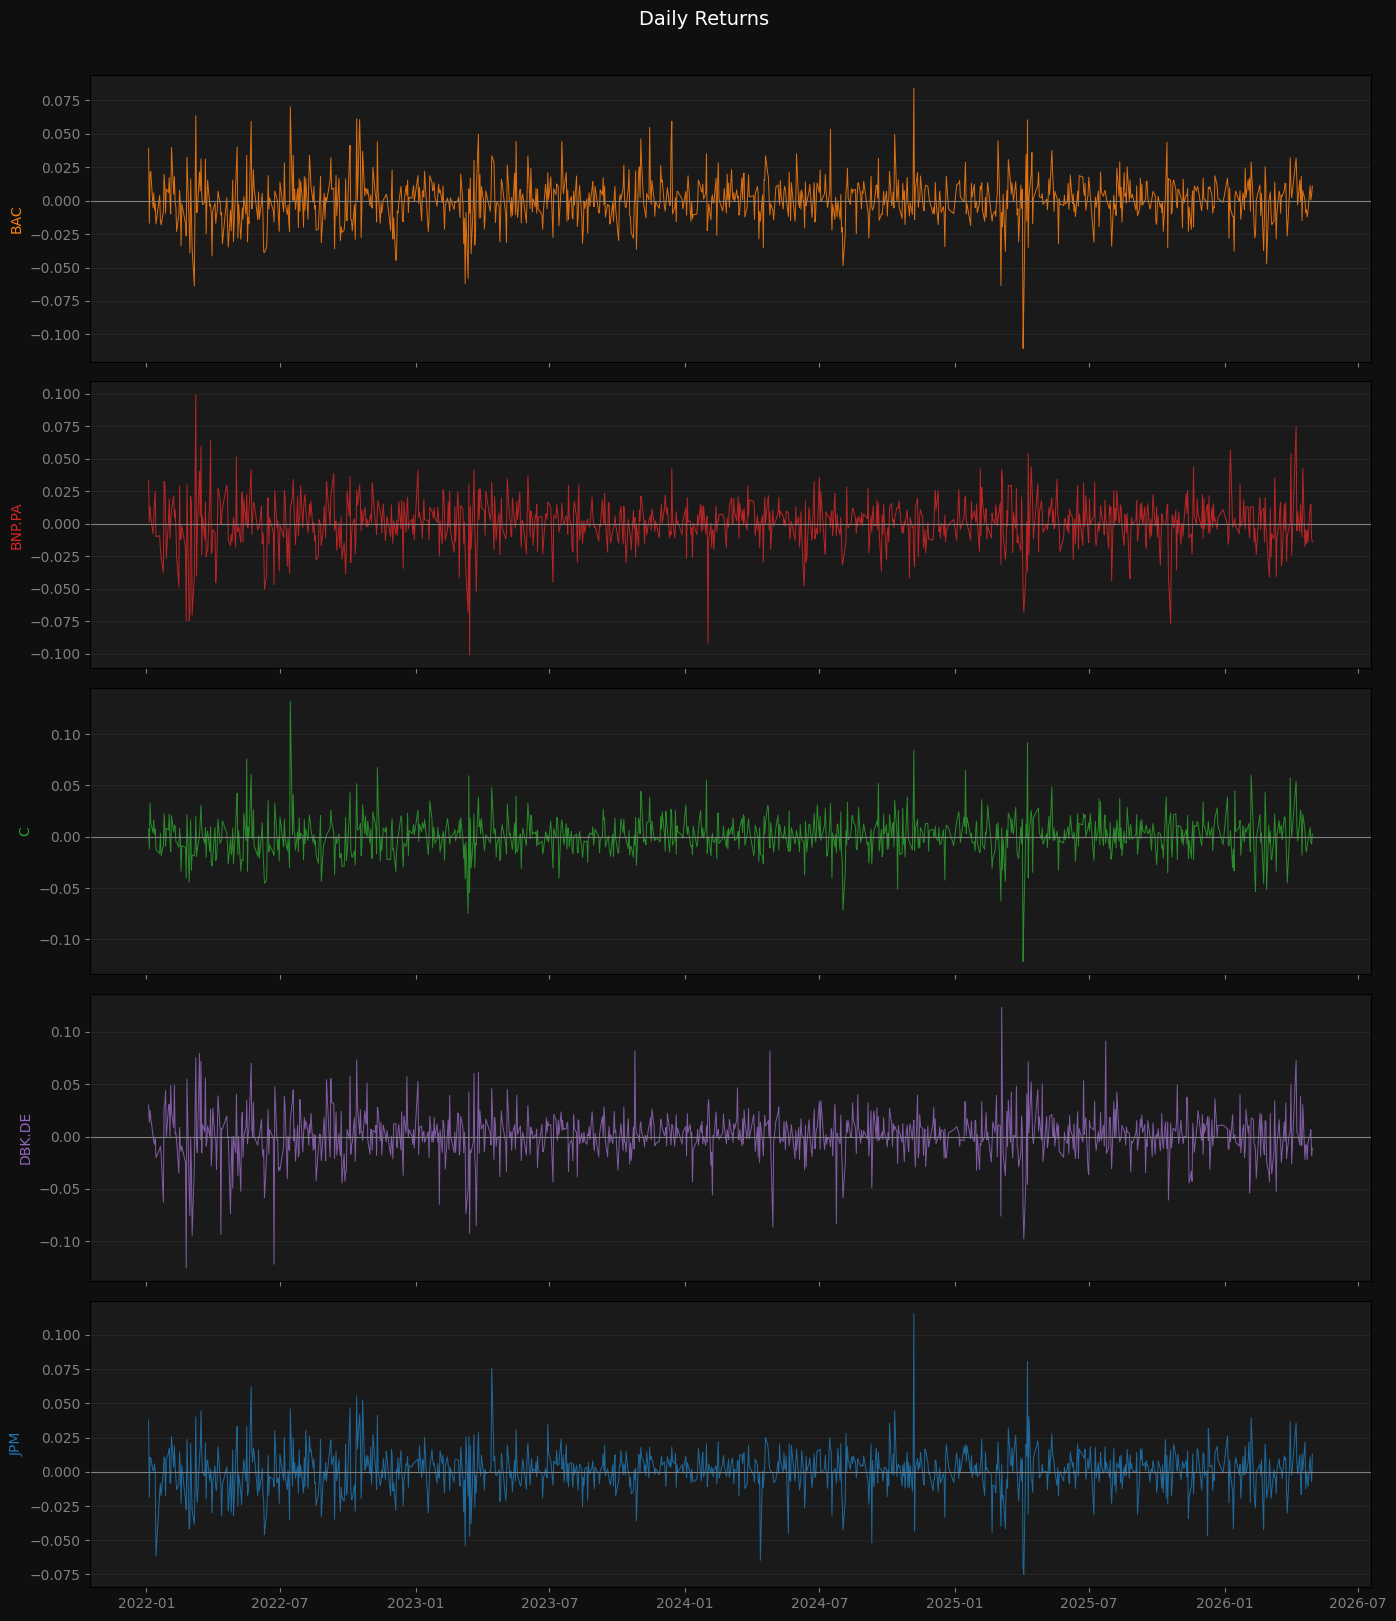

In [8]:
fig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=True) # We plot with subplots, as all are centered near 0 and it is not possible to distinguish in one plot
fig.patch.set_facecolor("#0F0F0F")
fig.suptitle("Daily Returns", color="white", fontsize=14, y=1.01)

for ax, ticker in zip(axes, daily_returns.columns):
    ax.set_facecolor("#1A1A1A")
    ax.plot(daily_returns.index, daily_returns[ticker], color=colors[ticker], linewidth=0.7, alpha=0.85)
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.set_ylabel(ticker, color=colors[ticker], fontsize=10)
    ax.tick_params(colors="gray")
    ax.grid(axis="y", color="#2A2A2A", linewidth=0.5)

plt.tight_layout()
plt.savefig("plots_bank/daily_returns.png",facecolor=fig.get_facecolor())
plt.show()


Plot 3: Log daily returns

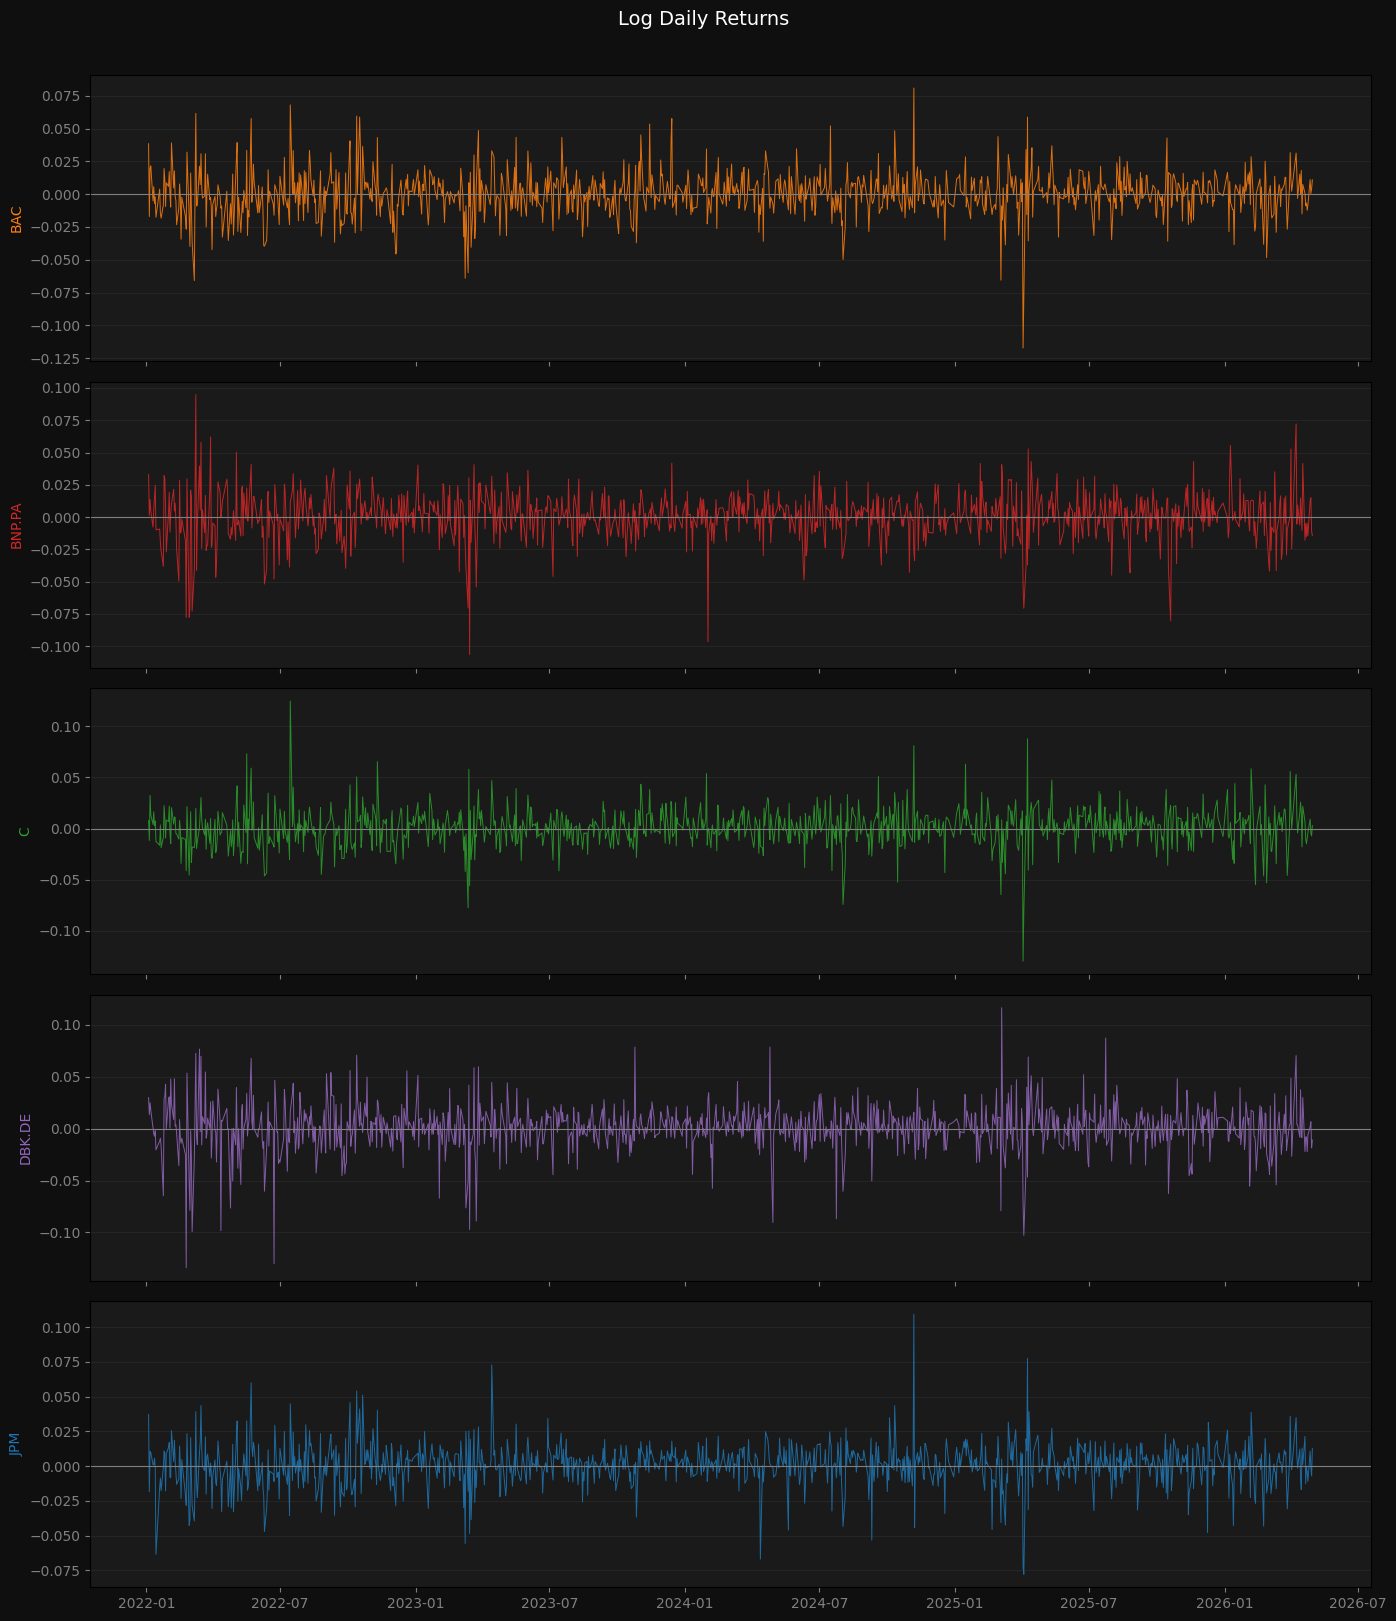

In [9]:
fig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=True)
fig.patch.set_facecolor("#0F0F0F")
fig.suptitle("Log Daily Returns", color="white", fontsize=14, y=1.01)

for ax, ticker in zip(axes, log_daily_returns.columns):
    ax.set_facecolor("#1A1A1A")
    ax.plot(log_daily_returns.index, log_daily_returns[ticker], color=colors[ticker], linewidth=0.7, alpha=0.85)
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.set_ylabel(ticker, color=colors[ticker], fontsize=10)
    ax.tick_params(colors="gray")
    ax.grid(axis="y", color="#2A2A2A", linewidth=0.5)

plt.tight_layout()
plt.savefig("plots_bank/log_daily_returns.png",facecolor=fig.get_facecolor())
plt.show()

In [10]:
# Statistics for daily returns

summary_daily = daily_returns.describe().T
summary_daily["skewness"] = daily_returns.skew()
summary_daily["kurtosis"] = daily_returns.kurt()

summary_daily

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Ticker,,,,,,,,,,
BAC,1024.0,0.000418,0.017243,-0.110633,-0.008911,0.000313,0.009106,0.084288,-0.052509,3.794045
BNP.PA,1024.0,0.000735,0.018514,-0.101071,-0.008388,0.001443,0.011435,0.099540,-0.487186,3.699920
C,1024.0,0.000978,0.018945,-0.121377,-0.009421,0.001143,0.010657,0.132306,0.208276,5.640644
DBK.DE,1024.0,0.001183,0.023215,-0.125369,-0.009143,0.001216,0.012178,0.123566,-0.385346,4.553154
JPM,1024.0,0.000828,0.015828,-0.074838,-0.007075,0.001348,0.009117,0.115445,0.136941,5.477507


In [11]:
# Statistics for daily log returns

summary_log_daily = log_daily_returns.describe().T
summary_log_daily["skewness"] = log_daily_returns.skew()
summary_log_daily["kurtosis"] = log_daily_returns.kurt()

summary_log_daily

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Ticker,,,,,,,,,,
BAC,1024.0,0.000270,0.017259,-0.117245,-0.008951,0.000313,0.009065,0.080924,-0.205997,4.118263
BNP.PA,1024.0,0.000562,0.018603,-0.106551,-0.008423,0.001442,0.011370,0.094892,-0.640384,3.962520
C,1024.0,0.000799,0.018915,-0.129399,-0.009465,0.001142,0.010601,0.124257,-0.005939,5.593499
DBK.DE,1024.0,0.000911,0.023333,-0.133953,-0.009185,0.001216,0.012105,0.116508,-0.612153,4.964058
JPM,1024.0,0.000703,0.015812,-0.077787,-0.007100,0.001347,0.009075,0.109254,-0.033493,5.052121


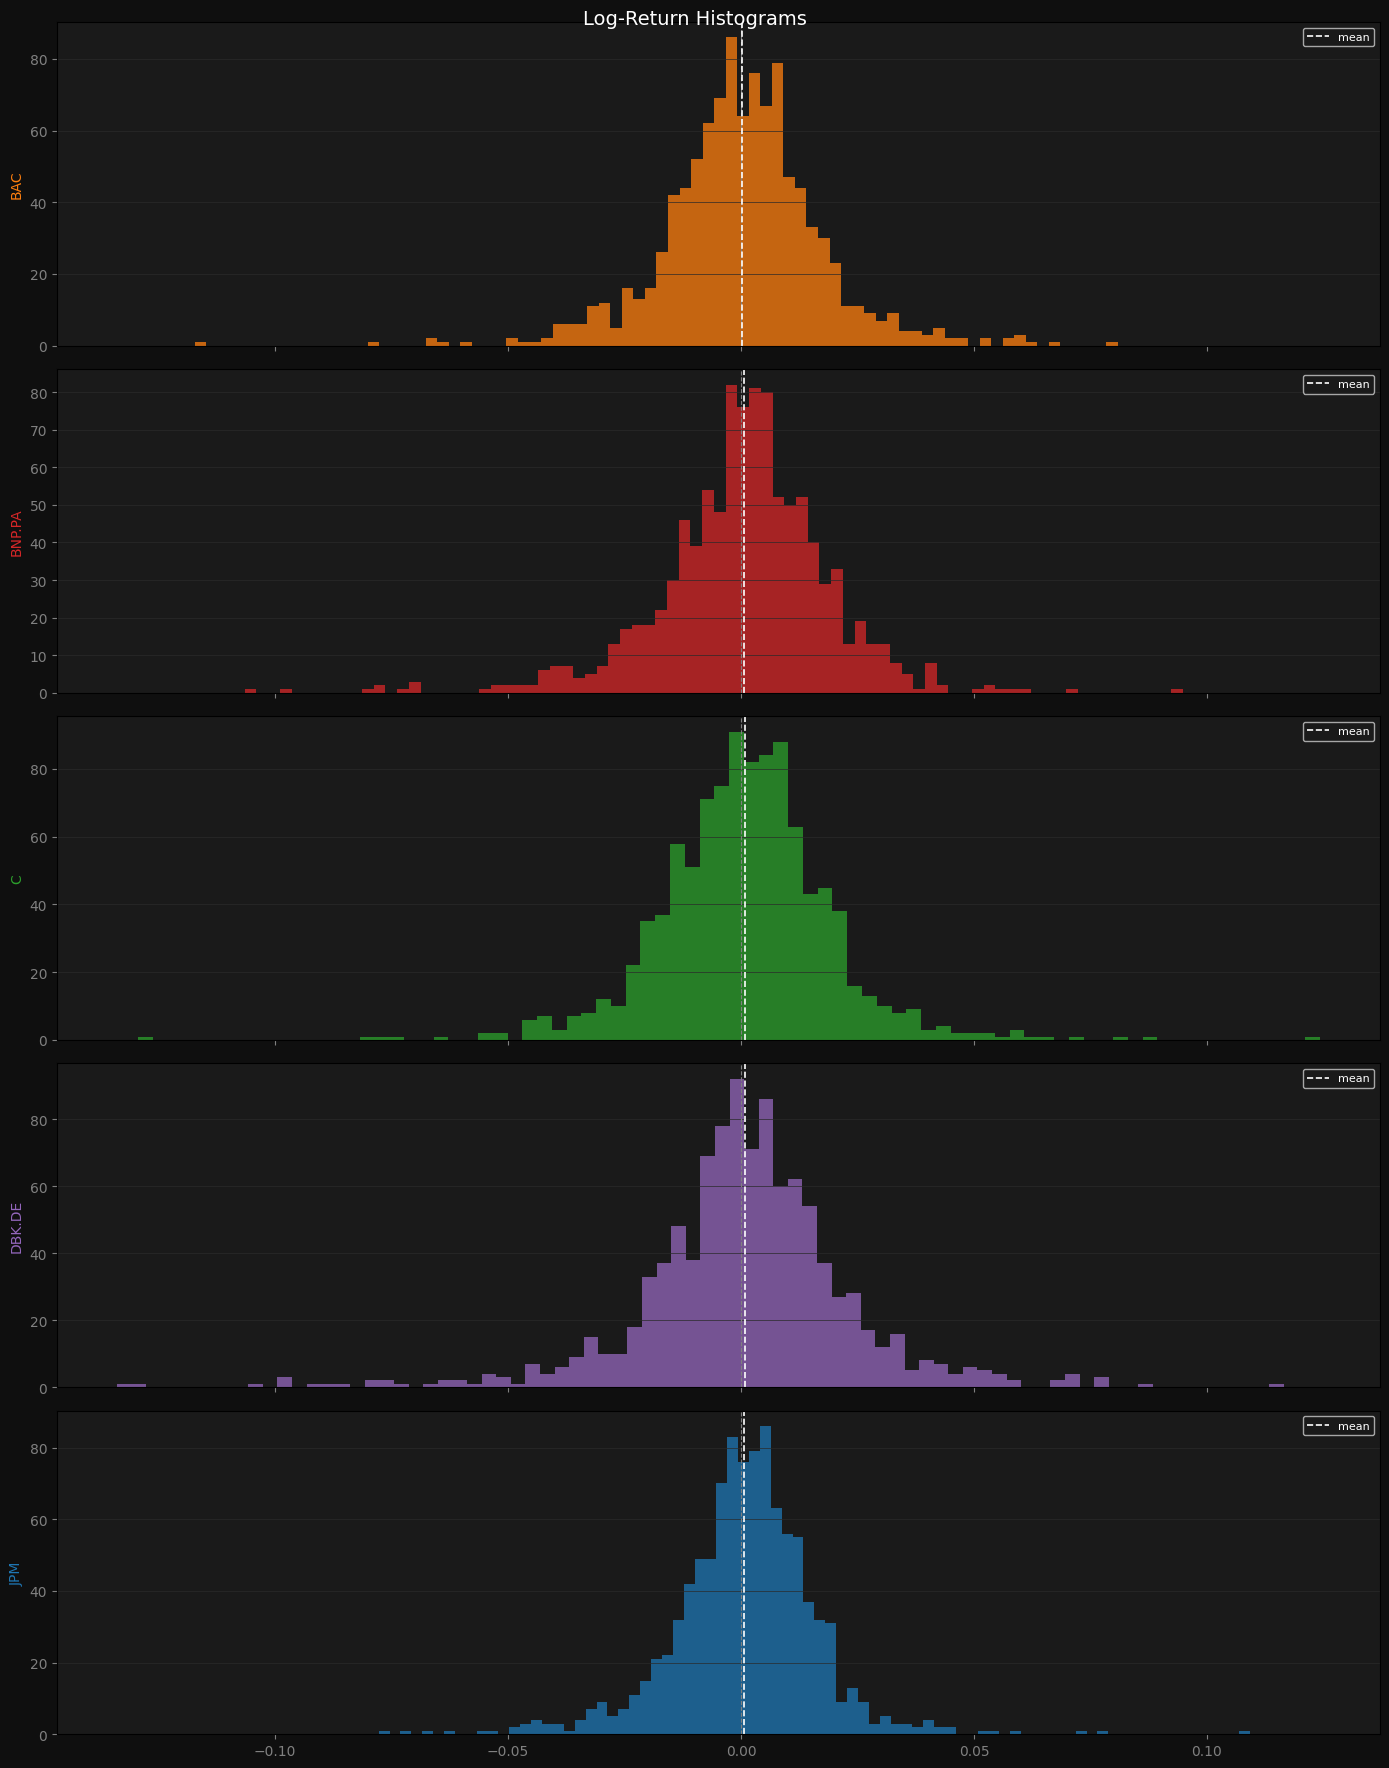

In [12]:
# Figure 1: Hystograms
fig, axes = plt.subplots(5, 1, figsize=(14, 18), sharex=True)
fig.patch.set_facecolor("#0F0F0F")
fig.suptitle("Log-Return Histograms", color="white", fontsize=14)

for ax, ticker in zip(axes, log_daily_returns.columns):
    ax.set_facecolor("#1A1A1A")
    ax.hist(log_daily_returns[ticker].dropna(), bins=80, color=colors[ticker], alpha=0.75, edgecolor="none")
    ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.axvline(log_daily_returns[ticker].mean(), color="white", linewidth=1.2, linestyle="--", label="mean")
    ax.set_ylabel(ticker, color=colors[ticker], fontsize=10)
    ax.tick_params(colors="gray")
    ax.grid(axis="y", color="#2A2A2A", linewidth=0.5)
    ax.legend(facecolor="#1A1A1A", labelcolor="white", fontsize=8)

plt.tight_layout()
plt.savefig("plots_bank/histograms.png", facecolor=fig.get_facecolor())
plt.show()

/tmp/ipykernel_17800/3916191429.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


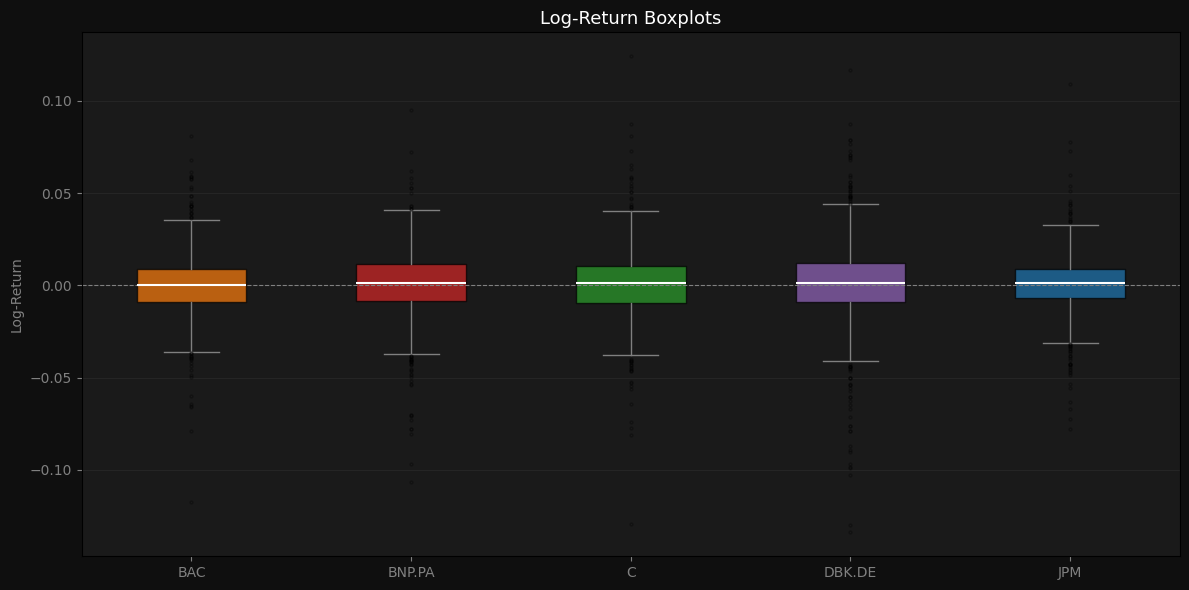

In [13]:
# Figure 2: Boxplots
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor("#0F0F0F")
ax.set_facecolor("#1A1A1A")

bp = ax.boxplot(
    [log_daily_returns[ticker] for ticker in log_daily_returns.columns],
    labels=log_daily_returns.columns,
    patch_artist=True,
    medianprops=dict(color="white", linewidth=1.5),
    whiskerprops=dict(color="gray"),
    capprops=dict(color="gray"),
    flierprops=dict(marker="o", markersize=2, alpha=0.3)
)

for patch, ticker in zip(bp["boxes"], log_daily_returns.columns):
    patch.set_facecolor(colors[ticker])
    patch.set_alpha(0.7)

for flier, ticker in zip(bp["fliers"], log_daily_returns.columns):
    flier.set_color(colors[ticker])

ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_title("Log-Return Boxplots", color="white", fontsize=13)
ax.set_ylabel("Log-Return", color="gray")
ax.tick_params(colors="gray")
ax.grid(axis="y", color="#2A2A2A", linewidth=0.5)

plt.tight_layout()
plt.savefig("plots_bank/boxplots.png", facecolor=fig.get_facecolor())
plt.show()

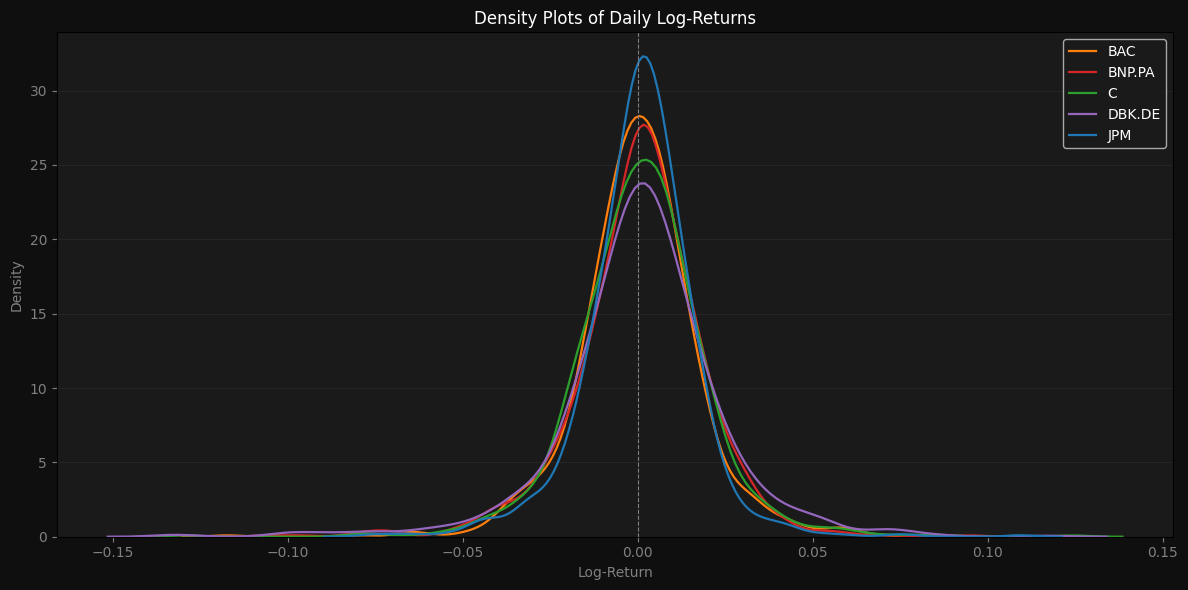

In [14]:
# Figure 3: Density plots

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor("#0F0F0F")
ax.set_facecolor("#1A1A1A")

for ticker in log_daily_returns.columns:
    sns.kdeplot(
        log_daily_returns[ticker].dropna(),
        ax=ax,
        color=colors[ticker],
        label=ticker,
        linewidth=1.6
    )

ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_title("Density Plots of Daily Log-Returns", color="white")
ax.set_xlabel("Log-Return", color="gray")
ax.set_ylabel("Density", color="gray")
ax.tick_params(colors="gray")
ax.grid(axis="y", color="#2A2A2A", linewidth=0.5)
ax.legend(facecolor="#1A1A1A", labelcolor="white", framealpha=0.8)

plt.tight_layout()
plt.savefig("plots_bank/density_plots.png", facecolor=fig.get_facecolor())
plt.show()

In [15]:
# Risk and performance metrics

risk_metrics = pd.DataFrame(index=log_daily_returns.columns)

risk_metrics["Mean daily return"] = log_daily_returns.mean()
risk_metrics["Annualized return"] = log_daily_returns.mean() * 252
risk_metrics["Annualized volatility"] = log_daily_returns.std() * np.sqrt(252)
risk_metrics["Sharpe ratio"] = risk_metrics["Annualized return"] / risk_metrics["Annualized volatility"]

# Historical Value-at-Risk and Expected Shortfall at 95%
risk_metrics["VaR 95%"] = log_daily_returns.quantile(0.05)

risk_metrics["Expected Shortfall 95%"] = [
    log_daily_returns[ticker][log_daily_returns[ticker] <= log_daily_returns[ticker].quantile(0.05)].mean()
    for ticker in log_daily_returns.columns
]

risk_metrics

,Mean daily return,Annualized return,Annualized volatility,Sharpe ratio,VaR 95%,Expected Shortfall 95%
Ticker,,,,,,
BAC,0.000270,0.067982,0.273976,0.248131,-0.028338,-0.039494
BNP.PA,0.000562,0.141742,0.295308,0.479981,-0.029859,-0.046425
C,0.000799,0.201413,0.300266,0.670780,-0.028009,-0.042063
DBK.DE,0.000911,0.229655,0.370398,0.620022,-0.034135,-0.058650
JPM,0.000703,0.177222,0.251005,0.706050,-0.024999,-0.038027


The normalized price plot shows that the selected banking stocks do not move identically, even though all firms belong to the banking sector. So sector exposure is important, but it does not fully explain stock performance. Geographic market differences, bank-specific risk, interest-rate exposure, and investor perception also of course affect price dynamics.

Returns fluctuate around zero, as expected. The presence of sharp spikes is llikely caused by the banking sector's sensitiveness to macroeconomic news/shocks, interest-rate expectations, credit conditions, and financial-sector stress.

Deutsche Bank has the highest daily volatility among the selected banks, while JPMorgan has the lowest annualized volatility. Deutsche Bank also has the largest Expected Shortfall at the 95% level, meaning that in the worst 5% of trading days, its average loss is the most severe among the five banks. JPMorgan has the highest Sharpe ratio, thus the strongest risk-adjusted performance among the selected banks' stocks.

The return distributions are centered close to zero but have heavy tails. The kurtosis values are positive and relatively large, especially for Citigroup and JPMorgan, confirming the presence of fat tails. This is important because normality-based risk models may underestimate the probability of large daily losses.


# Part 3: Comparative and Interrelation Analysis

In [16]:
corr_matrix = log_daily_returns.corr()
corr_matrix

Ticker,BAC,BNP.PA,C,DBK.DE,JPM
Ticker,,,,,
BAC,1.000000,0.400697,0.811556,0.407421,0.796407
BNP.PA,0.400697,1.000000,0.379467,0.685309,0.358845
C,0.811556,0.379467,1.000000,0.414402,0.762256
DBK.DE,0.407421,0.685309,0.414402,1.000000,0.392968
JPM,0.796407,0.358845,0.762256,0.392968,1.000000


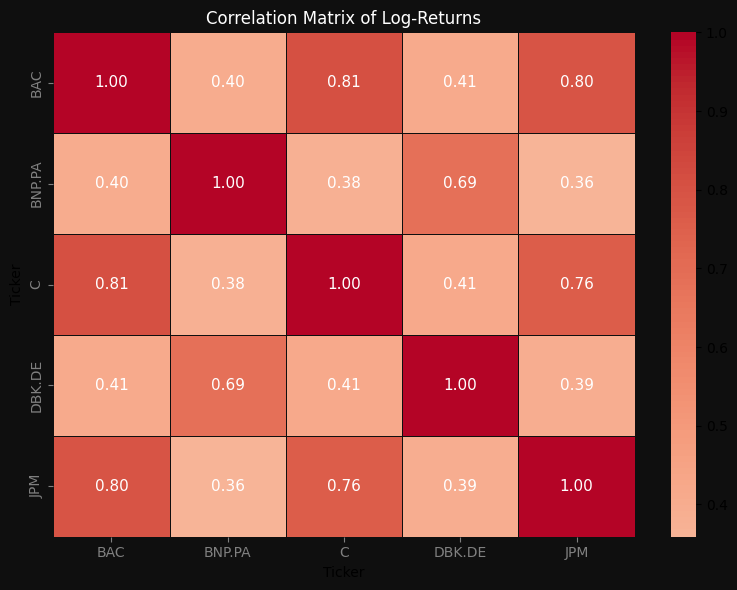

In [17]:
# Figure 1: heatmap

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor("#0F0F0F")
ax.set_facecolor("#1A1A1A")

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5, linecolor="#0F0F0F", annot_kws={"size": 11, "color": "white"}, ax=ax)

ax.set_title("Correlation Matrix of Log-Returns", color="white")
ax.tick_params(colors="gray")
plt.setp(ax.get_xticklabels(), color="gray")
plt.setp(ax.get_yticklabels(), color="gray")

plt.tight_layout()
plt.savefig("plots_bank/heatmap.png", facecolor=fig.get_facecolor())
plt.show()

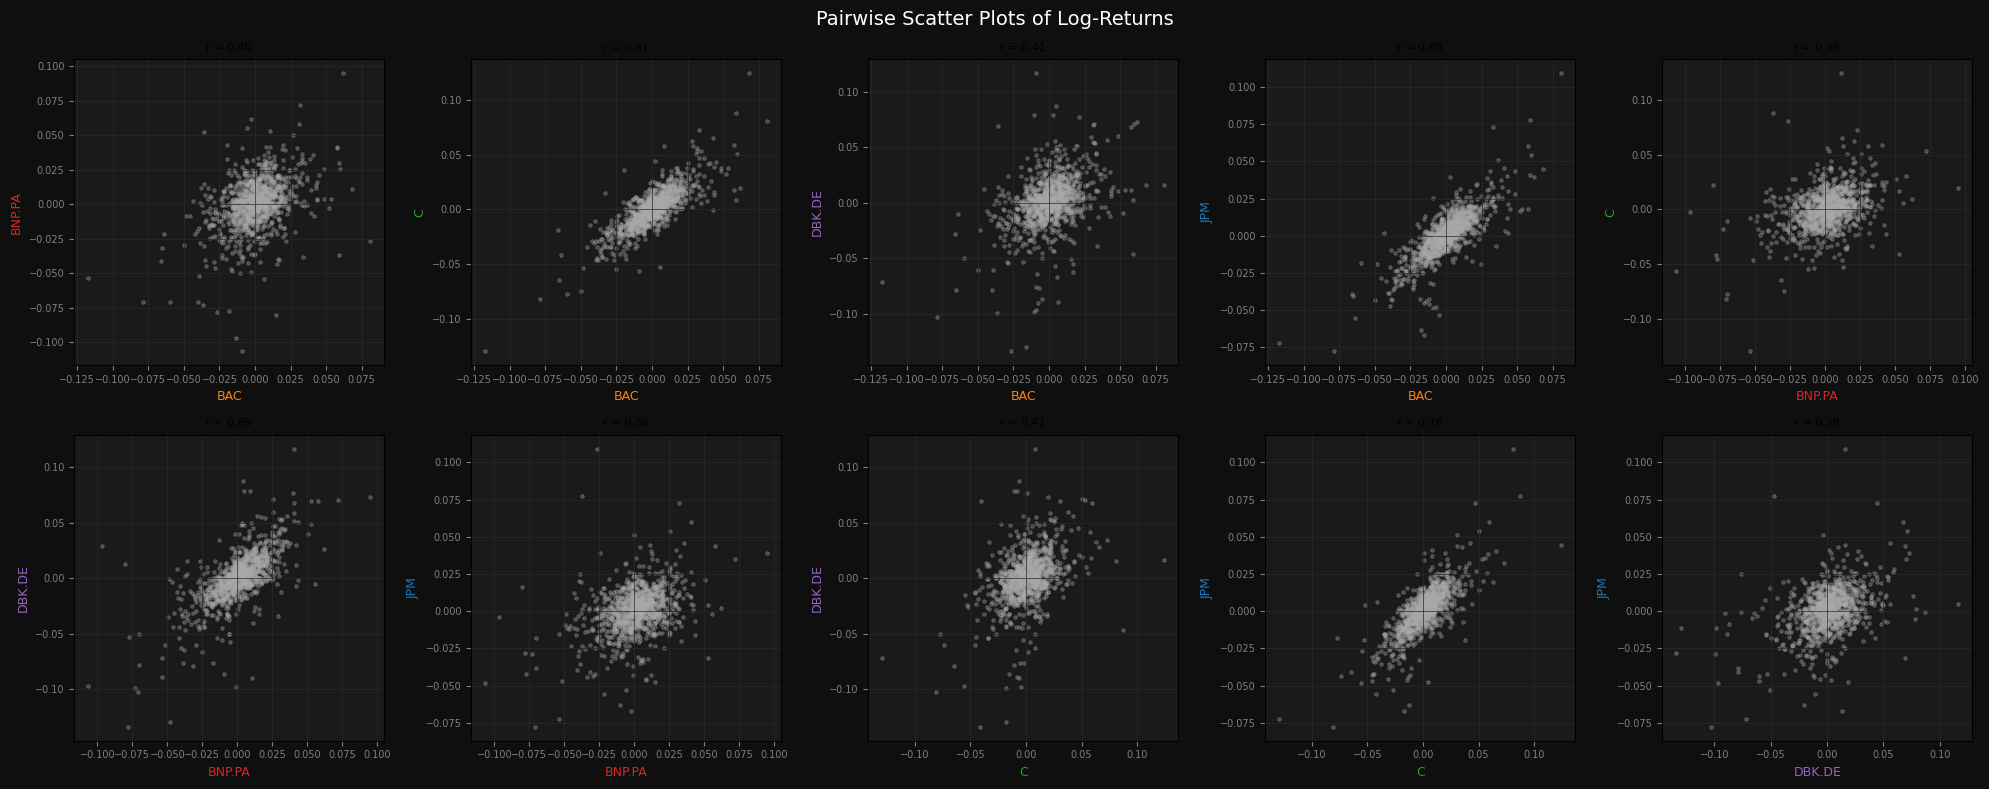

In [18]:
# Figure 2: Scatter Plots
tickers = log_daily_returns.columns.tolist()
pairs = [(tickers[i], tickers[j]) for i in range(len(tickers)) for j in range(i+1, len(tickers))]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.patch.set_facecolor("#0F0F0F")
fig.suptitle("Pairwise Scatter Plots of Log-Returns", color="white", fontsize=14)
axes = axes.flatten()

for ax, (t1, t2) in zip(axes, pairs):
    ax.set_facecolor("#1A1A1A")
    ax.scatter(log_daily_returns[t1], log_daily_returns[t2], alpha=0.3, s=6, color="#AAAAAA")
    ax.set_xlabel(t1, color=colors[t1], fontsize=9)
    ax.set_ylabel(t2, color=colors[t2], fontsize=9)
    ax.tick_params(colors="gray", labelsize=7)
    ax.grid(color="#2A2A2A", linewidth=0.5)

    r = log_daily_returns[t1].corr(log_daily_returns[t2])
    ax.set_title(f"r = {r:.2f}", fontsize=8)

plt.tight_layout()
plt.savefig("plots_bank/scatter_plots.png", facecolor=fig.get_facecolor())
plt.show()


The correlation matrix shows a clear regional structure with The three US banks strongly pairwise correlated, strongest among all namely Bank of America and Citigroup, Bank of America and JPMorgan, and Citigroup and JPMorgan comprising the top 3.So, US banking stocks share a large common component, likely driven by the effects of identical monetary policy, similar credit conditions, and financial-sector sentiment.

The European banks, BNP Paribas and Deutsche Bank, are also strongly correlated, but their correlations with US banks are lower. The takeaway si that geographic diversification still provides some diversification benefit, even within the same sector. However, all pairwise correlations remain positive, so the selected banks are not independent risk exposures, whcih was expected considering all come from the same sector.

# Part 4: Hypothesis Testing and Statistical Inference

In [19]:
# Test 1: Mean daily log-return different from zero
# H0: The true mean daily log-return of the stock is equal to 0.
# H1: The true mean daily log-return of the stock is not equal to 0.
# Significance level: alpha = 0.05.
# We use HAC standard errors to make the test more robust to heteroskedasticity

alpha = 0.05
mean_test_results = []

for ticker in log_daily_returns.columns:
    y = log_daily_returns[ticker].dropna()
    X = np.ones((len(y), 1))

    model = sm.OLS(y.values, X).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": 5}
    )

    mean_test_results.append({
        "Ticker": ticker,
        "Mean daily log-return": y.mean(),
        "Annualized mean return": y.mean() * 252,
        "HAC t-stat": model.tvalues[0],
        "HAC p-value": model.pvalues[0],
        "Reject H0 at 5%": model.pvalues[0] < alpha
    })

mean_test_results = pd.DataFrame(mean_test_results)
mean_test_results

,Ticker,Mean daily log-return,Annualized mean return,HAC t-stat,HAC p-value,Reject H0 at 5%
0,BAC,0.000270,0.067982,0.457599,0.647241,False
1,BNP.PA,0.000562,0.141742,0.917872,0.358686,False
2,C,0.000799,0.201413,1.295034,0.195308,False
3,DBK.DE,0.000911,0.229655,1.230458,0.218526,False
4,JPM,0.000703,0.177222,1.386092,0.165719,False


For the first hypothesis test, we test whether each bank’s average daily log-return is significantly different from zero. Using HAC standard errors, we fail to reject the null hypothesis for all five banks at the 5% significance level. Although the sample mean returns are positive, the evidence is not strong enough to conclude that the true average daily return is statistically different from zero

In [20]:
# Test 2: Mean return difference between US and European bank portfolios
# We first construct an equally weighted US bank portfolio and an equally weighted European bank portfolio.
# H0: The true mean difference between the US and European bank portfolio log-returns is equal to 0.
# H1: The true mean difference between the US and European bank portfolio log-returns is not equal to 0.
# Significance level: alpha = 0.05.
# The tested variable is:
#     return_spread = US bank portfolio return - European bank portfolio return


us_banks = ["JPM", "BAC", "C"]
european_banks = ["BNP.PA", "DBK.DE"]

us_portfolio = log_daily_returns[us_banks].mean(axis=1)
eu_portfolio = log_daily_returns[european_banks].mean(axis=1)

return_spread = (us_portfolio - eu_portfolio).dropna()

X = np.ones((len(return_spread), 1))

spread_model = sm.OLS(return_spread.values, X).fit(
    cov_type="HAC",
    cov_kwds={"maxlags": 5}
)

print("H0: Mean return difference between US and European bank portfolios is zero.")
print("H1: Mean return difference is not zero.")
print(f"HAC t-stat: {spread_model.tvalues[0]:.4f}")
print(f"HAC p-value: {spread_model.pvalues[0]:.4f}")
print(f"Reject H0 at 5%: {spread_model.pvalues[0] < alpha}")

H0: Mean return difference between US and European bank portfolios is zero.
H1: Mean return difference is not zero.
HAC t-stat: -0.2984
HAC p-value: 0.7654
Reject H0 at 5%: False


For the second hypothesis test, we compare the average daily log-return of the US bank portfolio with the European bank portfolio. The p-value is 0.7654, so we fail to reject the null hypothesis that the two portfolio mean returns are equal. This suggests that, over the sample period, the average return difference between the US and European banking groups is not statistically significant.

In [21]:
# Test 3: Kolmogorov-Smirnov test for normality
# For each stock, we test whether its standardized daily log-returns are consistent
# with the standard normal distribution.
#
# H0: The standardized daily log-returns follow a standard normal distribution.
# H1: The standardized daily log-returns do not follow a standard normal distribution.
# Significance level: alpha = 0.05.
#
# Before applying the test, each return series is standardized:
#     z = (return - sample mean) / sample standard deviation
# This allows us to compare each stock's return distribution to N(0, 1).
#
normality_results = []

for ticker in log_daily_returns.columns:
    x = log_daily_returns[ticker].dropna()

    # Standardize returns before comparing with standard normal distribution
    z = (x - x.mean()) / x.std(ddof=1)

    ks_stat, ks_p = stats.kstest(z, "norm")

    normality_results.append({
        "Ticker": ticker,
        "KS statistic": ks_stat,
        "p-value": ks_p,
        "Reject normality at 5%": ks_p < alpha
    })

normality_results = pd.DataFrame(normality_results)
normality_results

,Ticker,KS statistic,p-value,Reject normality at 5%
0,BAC,0.057789,2.052839e-03,True
1,BNP.PA,0.069685,9.077358e-05,True
2,C,0.058172,1.873759e-03,True
3,DBK.DE,0.086097,4.714888e-07,True
4,JPM,0.068900,1.135336e-04,True


For the third hypothesis test, the Kolmogorov-Smirnov test rejects normality for all five banks at the 5% significance level. This supports the initial observation of heavy tails.

# Part 5: Modeling

In [22]:
X = log_daily_returns[["BAC", "C", "BNP.PA", "DBK.DE"]]
y = log_daily_returns["JPM"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    JPM   R-squared:                       0.676
Model:                            OLS   Adj. R-squared:                  0.674
Method:                 Least Squares   F-statistic:                     530.6
Date:                Fri, 29 May 2026   Prob (F-statistic):          2.59e-247
Time:                        16:32:35   Log-Likelihood:                 3370.5
No. Observations:                1024   AIC:                            -6731.
Df Residuals:                    1019   BIC:                            -6706.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0003      0.000      1.162      0.2

In [23]:
model_data = pd.concat(
    [
        log_daily_returns["JPM"].rename("JPM_t"),
        log_daily_returns.shift(1).add_suffix("_lag1")
    ],
    axis=1
).dropna()

split_index = int(len(model_data) * 0.8)

train = model_data.iloc[:split_index]
test = model_data.iloc[split_index:]

X_train = train.drop(columns=["JPM_t"])
y_train = train["JPM_t"]

X_test = test.drop(columns=["JPM_t"])
y_test = test["JPM_t"]

X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test, has_constant="add")

predictive_model = sm.OLS(y_train, X_train).fit(
    cov_type="HAC",
    cov_kwds={"maxlags": 5}
)

y_pred = predictive_model.predict(X_test)

mse_model = np.mean((y_test - y_pred) ** 2)
rmse_model = np.sqrt(mse_model)

baseline_pred = pd.Series(y_train.mean(), index=y_test.index)
mse_baseline = np.mean((y_test - baseline_pred) ** 2)
rmse_baseline = np.sqrt(mse_baseline)

out_of_sample_r2 = 1 - (mse_model / mse_baseline)
directional_accuracy = (np.sign(y_pred) == np.sign(y_test)).mean()

print(predictive_model.summary())
print()
print(f"Out-of-sample RMSE: {rmse_model:.6f}")
print(f"Baseline RMSE: {rmse_baseline:.6f}")
print(f"Out-of-sample R²: {out_of_sample_r2:.4f}")
print(f"Directional accuracy: {directional_accuracy:.2%}")

                            OLS Regression Results                            
Dep. Variable:                  JPM_t   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                    0.9949
Date:                Fri, 29 May 2026   Prob (F-statistic):              0.420
Time:                        16:32:35   Log-Likelihood:                 2213.1
No. Observations:                 818   AIC:                            -4414.
Df Residuals:                     812   BIC:                            -4386.
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0006      0.001      1.063      

The lagged predictive regression examines whether yesterday’s returns of the five banks can predict today’s JPMorgan return. The model has very low explanatory power, with an in-sample R² of 0.009. None of the lagged return coefficients are statistically significant at conventional levels. The out-of-sample R² is negative, meaning the predictive regression performs slightly worse than a simple baseline that predicts the historical mean return. Directional accuracy is approximately 50.73%, which is close to random guessing.

The result seems reasonable. Daily stock returns are difficult to predict using only lagged returns, especially for liquid banking stocks. The model is still useful because it shows that strong same-sector correlations do not necessarily imply short-term predictability.

In [24]:
standardized_returns = (
    log_daily_returns - log_daily_returns.mean()
) / log_daily_returns.std()

U, S, Vt = np.linalg.svd(standardized_returns.values, full_matrices=False)

bank_factor_1 = pd.Series(
    U[:, 0] * S[0],
    index=standardized_returns.index,
    name="Banking_Factor_1"
)

loadings = pd.Series(
    Vt[0],
    index=standardized_returns.columns,
    name="PC1 Loading"
)

explained_variance_ratio = S[0] ** 2 / np.sum(S ** 2)

print(f"Variance explained by first common banking factor: {explained_variance_ratio:.2%}")
loadings

Variance explained by first common banking factor: 63.87%


,PC1 Loading
Ticker,
BAC,-0.494236
BNP.PA,-0.373688
C,-0.487049
DBK.DE,-0.386432
JPM,-0.479105


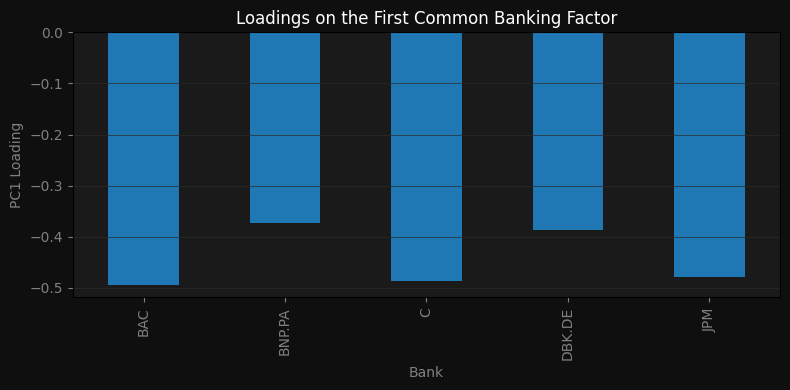

In [25]:
# Plot PCA loadings

fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor("#0F0F0F")
ax.set_facecolor("#1A1A1A")

loadings.plot(kind="bar", ax=ax)

ax.tick_params(colors="gray")
ax.set_title("Loadings on the First Common Banking Factor", color="white")
ax.set_ylabel("PC1 Loading", color="gray")
ax.set_xlabel("Bank", color="gray")
ax.grid(axis="y", color="#2A2A2A", linewidth=0.5)

plt.tight_layout()
plt.savefig("plots_bank/pca_common_factor_loadings.png", facecolor=fig.get_facecolor())
plt.show()

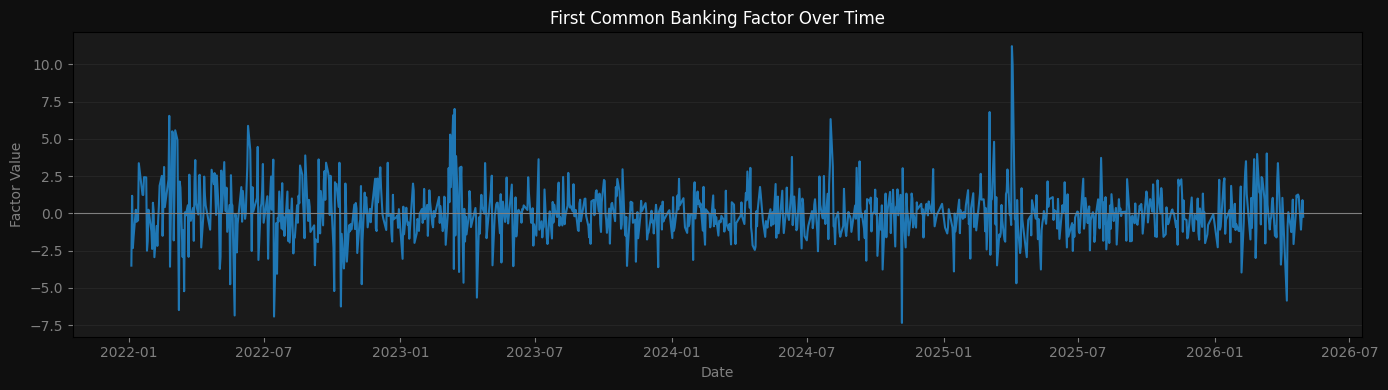

In [26]:
# Plot common banking factor over time

fig, ax = plt.subplots(figsize=(14, 4))
fig.patch.set_facecolor("#0F0F0F")
ax.set_facecolor("#1A1A1A")

ax.plot(
    bank_factor_1.index,
    bank_factor_1,
    color="#1f77b4",
    linewidth=1.5
)

ax.axhline(0, color="gray", linewidth=0.8)
ax.tick_params(colors="gray")
ax.set_title("First Common Banking Factor Over Time", color="white")
ax.set_ylabel("Factor Value", color="gray")
ax.set_xlabel("Date", color="gray")
ax.grid(axis="y", color="#2A2A2A", linewidth=0.5)

plt.tight_layout()
plt.savefig("plots_bank/common_banking_factor_timeseries.png", facecolor=fig.get_facecolor())
plt.show()

WIth PCA analysis, instead of predicting one stock, we extract a common banking factor from the standardized return series. The first principal component explains 63.87% of the total variation, so a single common factor captures a large share of co-movement across the five banking stocks. The loadings have similar signs across all banks, which indicates that the first component represents a broad banking-sector movement rather than a stock-specific effect. The US banks have slightly larger absolute loadings, suggesting that they contribute somewhat more strongly to the common factor in this sample. This may partly reflect the sample composition, since three of the five selected banks are US banks and they are strongly correlated with one another. It may also reflect the stronger role of large US banks in global financial markets.
